In [1]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

In [3]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')

In [5]:
allVirusData_chEMBL_wMACAW_MLready = pd.read_csv(modelBuildingDataDir + 'allVirusData_chEMBL_wMACAW_MLready.csv')
allVirusData_chEMBL_wMACAW_MLready.columns

Index(['ID', 'compound_id', 'Smiles', 'pPotency', 'VirusClassifier'], dtype='object')

In [6]:
first_entries = allVirusData_chEMBL_wMACAW_MLready.drop_duplicates(subset='VirusClassifier', keep='first').sort_values('VirusClassifier')
first_entries

,ID,compound_id,Smiles,pPotency,VirusClassifier
3444,13076,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.725842,Ebola
4691,14495,CHEMBL1631748,O=c1c(/C=N/Cc2ccco2)c(CSc2ccc(Cl)cc2)[nH]n1-c1...,8.886057,Hanta
4091,13800,CHEMBL2314868,CCOc1ccc(Cn2cnc3cc(NCc4ccc(CC)cc4)cnc32)cc1,5.795880,Lassa
4505,14292,CHEMBL5593581,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2cccnc2)CC1,4.413413,Marburg
3291,12855,CHEMBL2016757,N#C[C@@]1(c2ccc3c(N)ncnn23)O[C@H](CO)[C@@H](O)...,5.673664,Nipah
4282,14017,CHEMBL201212,CC(C)C[C@H](NC(=O)OCc1ccccc1)C(=O)NC(CCC(=O)N(...,5.443697,SARS-CoV
0,2,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,8.000000,SARS-CoV-2
3301,12865,CHEMBL5088695,COc1ccc(Nc2ccnc3ccc(C(F)(F)F)cc23)c(OC)c1,5.468521,VEEV


### virus distribution pie charts

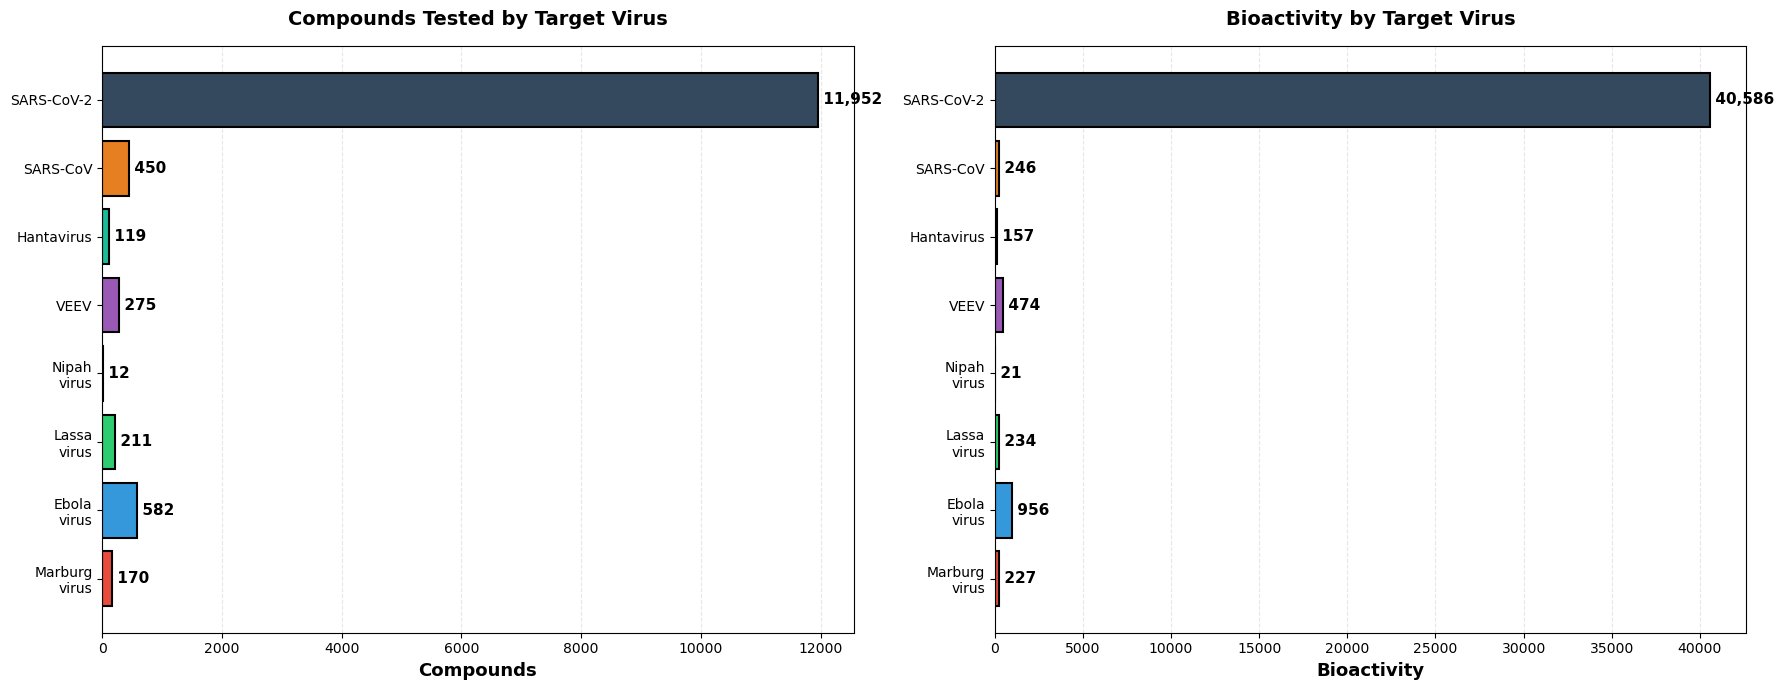

In [28]:
import matplotlib.pyplot as plt
import numpy as np


# Data
viruses = ['Marburg\nvirus', 'Ebola\nvirus', 'Lassa\nvirus', 'Nipah\nvirus', 
           'VEEV', 'Hantavirus', 'SARS-CoV', 'SARS-CoV-2']
compounds = [170, 582, 211, 12, 275, 119, 450, 11952]
bioactivity = [227, 956, 234, 21, 474, 157, 246, 40586]

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Colors
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', 
          '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

# Bar chart 1: Compounds
bars1 = ax1.barh(viruses, compounds, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Compounds', fontsize=13, fontweight='bold')
ax1.set_title('Compounds Tested by Target Virus', fontsize=14, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Add value labels
for i, (bar, val) in enumerate(zip(bars1, compounds)):
    ax1.text(val, i, f' {val:,}', va='center', fontweight='bold', fontsize=11)

# Bar chart 2: Bioactivity
bars2 = ax2.barh(viruses, bioactivity, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Bioactivity', fontsize=13, fontweight='bold')
ax2.set_title('Bioactivity by Target Virus', fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# Add value labels
for i, (bar, val) in enumerate(zip(bars2, bioactivity)):
    ax2.text(val, i, f' {val:,}', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(resultsDir + 'virus/virus_distribution_bar_charts.png', dpi=300, bbox_inches='tight')
plt.show()

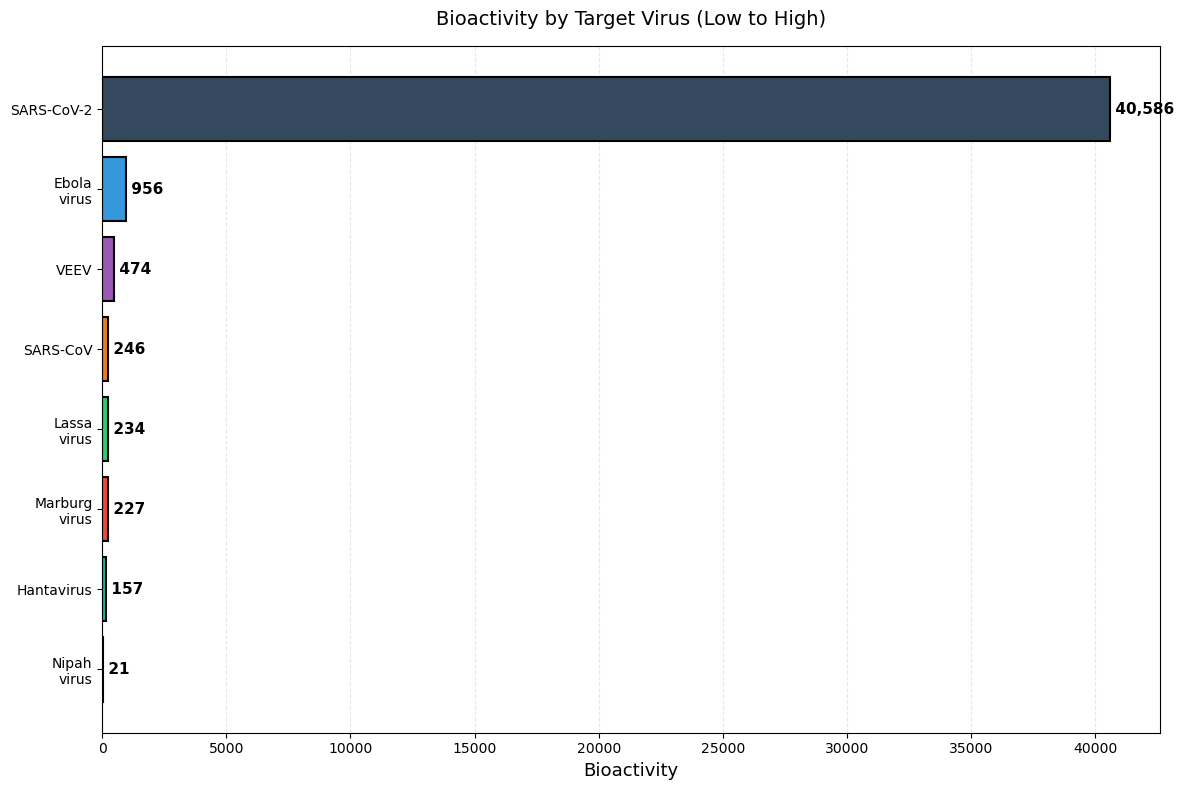

Sorted Order (Low to High):
1. Nipah virus                          21
2. Hantavirus                          157
3. Marburg virus                       227
4. Lassa virus                         234
5. SARS-CoV                            246
6. VEEV                                474
7. Ebola virus                         956
8. SARS-CoV-2                       40,586


In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Data
viruses = ['Marburg\nvirus', 'Ebola\nvirus', 'Lassa\nvirus', 'Nipah\nvirus', 
           'VEEV', 'Hantavirus', 'SARS-CoV', 'SARS-CoV-2']
bioactivity = [227, 956, 234, 21, 474, 157, 246, 40586]

# Sort data from low to high bioactivity
sorted_indices = np.argsort(bioactivity)
viruses_sorted = [viruses[i] for i in sorted_indices]
bioactivity_sorted = [bioactivity[i] for i in sorted_indices]

# Colors (maintain original color for each virus)
colors_original = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', 
                   '#9b59b6', '#1abc9c', '#e67e22', '#34495e']
colors_sorted = [colors_original[i] for i in sorted_indices]

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Bar chart: Bioactivity (sorted low to high)
bars = ax.barh(viruses_sorted, bioactivity_sorted, color=colors_sorted, 
               edgecolor='black', linewidth=1.5)
ax.set_xlabel('Bioactivity', fontsize=13)
ax.set_title('Bioactivity by Target Virus (Low to High)', fontsize=14, pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, bioactivity_sorted)):
    ax.text(val, i, f' {val:,}', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(resultsDir + 'virus/bioactivity_bar_chart_sorted.png', dpi=300, bbox_inches='tight')
plt.show()

# Print sorted order
print("="*60)
print("Sorted Order (Low to High):")
print("="*60)
for i, (virus, bio) in enumerate(zip(viruses_sorted, bioactivity_sorted), 1):
    print(f"{i}. {virus.replace(chr(10), ' '):30} {bio:>8,}")
print("="*60)

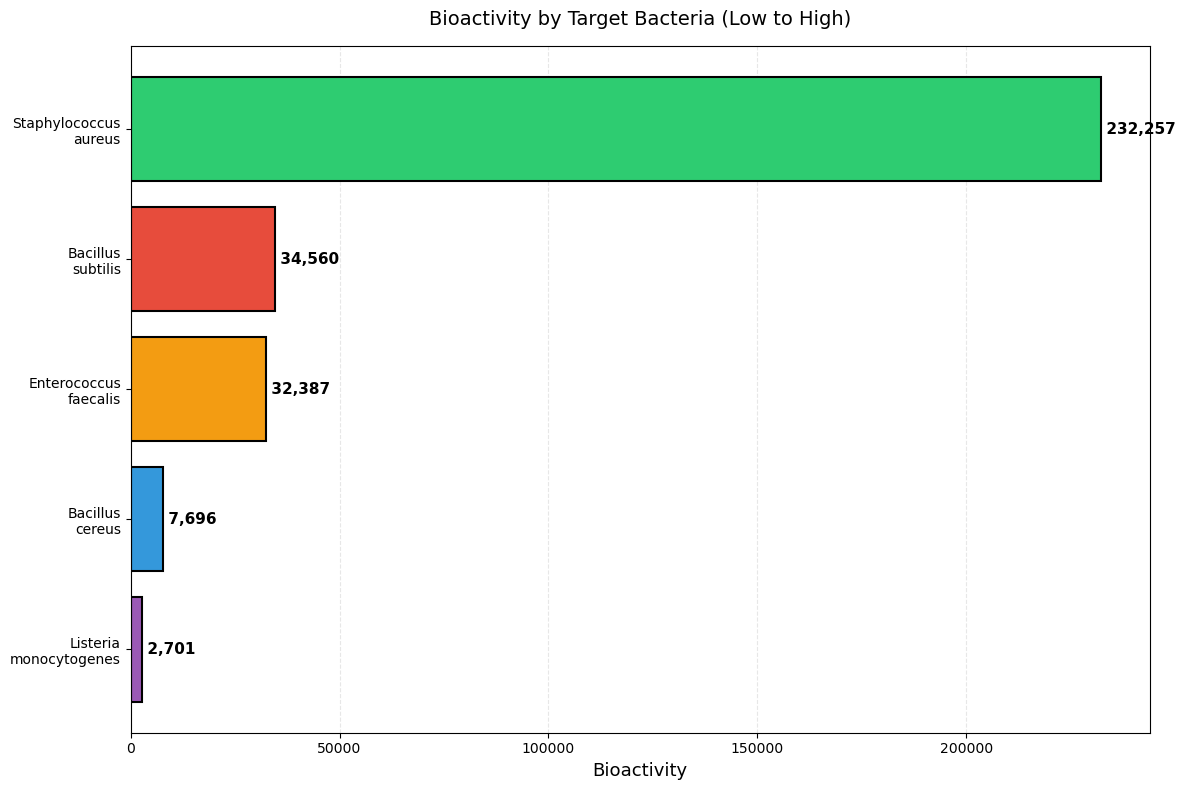

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Data - Bacteria
bacteria = ['Bacillus\nsubtilis', 'Bacillus\ncereus', 'Staphylococcus\naureus', 
            'Enterococcus\nfaecalis', 'Listeria\nmonocytogenes']
compounds = [23495, 5229, 83473, 19447, 1406]
bioactivity = [34560, 7696, 232257, 32387, 2701]

# Sort data from low to high bioactivity
sorted_indices = np.argsort(bioactivity)  # Get indices that would sort the array
bacteria_sorted = [bacteria[i] for i in sorted_indices]
bioactivity_sorted = [bioactivity[i] for i in sorted_indices]

# Colors (original order)
colors_original = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
colors_sorted = [colors_original[i] for i in sorted_indices]  # Maintain color association

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Bar chart: Bioactivity (sorted)
bars = ax.barh(bacteria_sorted, bioactivity_sorted, color=colors_sorted, 
               edgecolor='black', linewidth=1.5)
ax.set_xlabel('Bioactivity', fontsize=13)
ax.set_title('Bioactivity by Target Bacteria (Low to High)', fontsize=14, pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, bioactivity_sorted)):
    ax.text(val, i, f' {val:,}', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(resultsDir + 'Bacteria/bioactivity_bar_chart_sorted.png', dpi=300, bbox_inches='tight')
plt.show()

### Read Enamine Antivirals Data

https://enamine.net/compound-libraries/targeted-libraries/antiviral-library

In [19]:
EnamineAntiviralsData = pd.read_csv(dataDir + "Enamine_Antiviral_Library_plated_3200cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                     skiprows=1, skip_blank_lines=True)
print(EnamineAntiviralsData.shape)
EnamineAntiviralsData.head()

(3200, 11)


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,Z410227912,256.326,256.326,1.231,-2.190,2,4,76.14,5,https://real.enamine.net/public-enum-files/Z41...
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,Z383167688,237.256,237.256,-0.042,-0.692,1,3,69.72,5,https://real.enamine.net/public-enum-files/Z38...
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,Z235579208,306.404,306.404,1.583,-2.082,1,5,57.70,7,NaN
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,Z403694008,279.379,279.379,1.156,-0.660,1,3,58.37,7,https://real.enamine.net/public-enum-files/Z40...
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,Z384461492,307.389,307.389,1.084,-1.180,1,4,61.88,7,https://real.enamine.net/public-enum-files/Z38...


### Read Enamine Antibacterials Data

https://enamine.net/compound-libraries/targeted-libraries/antibacterial-library

In [20]:
EnamineAntibacterialsData = pd.read_csv(dataDir + "Enamine_Antibacterial_Library_plated_32000cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                     skiprows=1, skip_blank_lines=True)
print(EnamineAntibacterialsData.shape)
EnamineAntibacterialsData.head()

(32000, 11)


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,Z19065527,374.392,374.392,2.754,-4.286,0,6,111.60,6,https://real.enamine.net/public-enum-files/Z19...
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,Z1203040657,338.387,338.387,1.246,-4.006,2,5,124.50,8,https://real.enamine.net/public-enum-files/Z12...
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,Z19154552,384.449,384.449,2.021,-3.375,1,5,102.01,6,https://real.enamine.net/public-enum-files/Z19...
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,Z1509821346,346.409,346.409,1.094,-1.970,1,5,94.70,6,https://real.enamine.net/public-enum-files/Z15...
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,Z1509833014,341.768,341.768,2.254,-3.235,3,5,103.70,4,https://real.enamine.net/public-enum-files/Z15...


### Read Life chemicals Antivirals Data

https://lifechemicals.com/screening-libraries/targeted-and-focused-screening-libraries/antiviral-libraries

In [22]:
from rdkit import Chem


# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LC_Merged_Antiviral_Screening_Superset.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntiviralsData_superset = pd.DataFrame(records)

print(LCAntiviralsData_superset.shape)
LCAntiviralsData_superset

(45573, 17)


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,Acceptor,Donor,RotBonds,HAC,Collection,Library,PPDS,SMILES
0,F6544-0534,"11-(oxan-4-yl)-7,11-diazatricyclo[7.3.1.0²,⁷]t...",2034607-75-3,1.5,274.36,solid,0.69,-0.12,32.78,2,1,1,20.0,Advanced,Anti-Hepatitis_A_B_ Screening_Library,,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1
1,F6559-5304,6-[4-(trifluoromethyl)pyrimidin-2-yl]-6-azaspi...,2034225-11-9,1.5,301.26,solid,0.62,2.03,66.32,4,1,2,21.0,Advanced,2019-nCoV_Main_Protease_Targeted_Library,+,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2
2,F6610-6619,"1-methyl-4-[(pyridin-4-yl)methyl]-1,4-diazepane",2320860-02-2,1.0,205.30,oil,0.58,0.89,19.37,3,3,2,15.0,General,Anti-HIV_Focused_Library,,CN1CCCN(Cc2ccncc2)CC1
3,F6559-5274,"6-(4,6-dimethylpyrimidin-2-yl)-6-azaspiro[3.4]...",2034225-08-4,1.5,261.32,oil,0.64,2.09,66.32,4,1,2,19.0,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1
4,F1912-1536,N-cyclopropyl-N-(piperidin-4-yl)pyrimidin-4-amine,1781768-10-2,1.5,218.29,solid,0.67,0.79,41.05,2,2,3,16.0,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,c1cc(N(C2CCNCC2)C2CC2)ncn1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45568,F9995-0825,"1-ethyl-4-[(1E)-3-[(4E)-1-ethyl-1,4-dihydroqui...",19764-88-6,1.0,353.48,solid,0.16,1.68,7.12,1,1,4,27.0,General,Anti-HIV_Focused_Library,,CCN1C=C/C(=C\C=C\c2cc[n+](CC)c3ccccc23)c2ccccc...
45569,F9995-0872,"3-propyl-2-[(1E)-3-[(2Z)-3-propyl-2,3-dihydro-...",53336-12-2,1.0,393.59,solid,0.26,4.39,60.66,1,1,6,27.0,General,Antiviral_Screening_Compound_Library_2D_Simila...,,CCCN1/C(=C/C=C/c2sc3ccccc3[n+]2CCC)Sc2ccccc21....
45570,F9995-1239,methyl 2-(6-amino-3-imino-3H-xanthen-9-yl)benz...,62669-70-9,1.0,344.36,solid,0.05,2.33,85.40,5,2,3,26.0,General,Anti-HIV_Focused_Library,,COC(=O)c1ccccc1-c1c2ccc(=N)cc-2oc2cc(N)ccc12.Cl
45571,F9995-1294,5-chloro-2-[(E)-2-[(3E)-3-{2-[(2Z)-5-chloro-3-...,,1.0,679.74,solid,0.15,9.96,63.90,2,2,8,46.0,General,Antiviral_Screening_Compound_Library_2D_Simila...,,CCN1/C(=C/C=C2\CCC(/C=C/c3sc4ccc(Cl)cc4[n+]3CC...


### Read Life Chemicals AntiBiotic Data

https://lifechemicals.com/screening-libraries/targeted-and-focused-screening-libraries/antibacterial-library?

In [25]:
from rdkit import Chem


# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LC_Antibacterial_Focused_Library.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntibacterialsData = pd.DataFrame(records)

print(LCAntibacterialsData.shape)
LCAntibacterialsData

(15538, 26)


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,H-acceptors,...,Reference_ID,Activity_type,Activity_value_,Activity_units_,Activity_comment,Target_name,Target_organism,Target_type,SMILES,PPDS
0,F6540-4248,"6-(3-methoxypiperidin-1-yl)-N,N-dimethylpyrimi...",2097927-68-7,1.5,236.31,oil,0.67,1.60,41.49,3,...,CHEMBL4548594,Inhibition,37.21,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,COC1CCCN(c2cc(N(C)C)ncn2)C1,NaN
1,F6541-0830,"1-(5,6,7,8-tetrahydroquinazolin-4-yl)piperidin...",1541766-76-0,1.5,233.31,oil,0.69,1.51,49.25,3,...,CHEMBL4533334,Inhibition,26.56,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,OC1CCCN(c2ncnc3c2CCCC3)C1,NaN
2,F6541-5261,5-fluoro-2-[4-(propan-2-yl)piperazin-1-yl]pyri...,2034458-11-0,1.5,224.28,oil,0.64,1.46,32.26,3,...,CHEMBL4542429,Inhibition,25.16,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CC(C)N1CCN(c2ncc(F)cn2)CC1,NaN
3,F6543-7286,"6-(2,6-dimethylmorpholin-4-yl)-N,N-dimethylpyr...",2034461-31-7,1.5,236.31,solid,0.67,1.83,41.49,3,...,CHEMBL4548594,Inhibition,37.21,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,NaN
4,F6570-1027,1-[6-(dimethylamino)pyrimidin-4-yl]piperidin-3-ol,1903487-65-9,1.5,222.28,solid,0.64,0.84,52.49,3,...,CHEMBL4548594,Inhibition,37.21,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CN(C)c1cc(N2CCCC(O)C2)ncn1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15533,F0008-0880,"N-(3-{2,4-dioxo-3-azatricyclo[7.3.1.0^{5,13}]t...",393124-77-1,1.0,602.68,solid,0.07,9.36,66.92,4,...,CHEMBL1421347,EC50,1 267.00,nM,Active,Streptokinase A,Streptococcus pyogenes serotype M1,SINGLE PROTEIN,O=C1c2cccc3cccc(c23)C(=O)N1CCCN(C(=O)c1ccc(-c2...,NaN
15534,F0808-1826,"3-oxo-N-(4-{3-oxo-2-azatricyclo[6.3.1.0^{4,12}...",425410-31-7,1.0,570.60,solid,0.00,3.54,167.30,8,...,CHEMBL1611838,IC50,1 601.00,nM,active,Fructose-bisphosphate aldolase,Mycobacterium tuberculosis,SINGLE PROTEIN,O=C1Nc2ccc(S(=O)(=O)Nc3ccc(NS(=O)(=O)c4ccc5c6c...,+
15535,F1602-0313,(2Z)-5-(hydroxymethyl)-8-methyl-N-(naphthalen-...,866342-22-5,1.0,485.53,solid,0.06,5.94,83.81,5,...,CHEMBL200484,MIC,25,ug.mL-1,0,Escherichia coli,Escherichia coli,ORGANISM,Cc1ncc(CO)c2cc(C(=O)Nc3cccc4ccccc34)/c(=N/c3cc...,NaN
15536,F0382-0032,"ethyl 2-[4-(4-{[5-(ethoxycarbonyl)-4-phenyl-1,...",392251-66-0,1.0,718.80,solid,0.11,8.58,202.29,9,...,CHEMBL3126527,MBC,6.25,ug ml-1,0,Staphylococcus aureus,Staphylococcus aureus,ORGANISM,CCOC(=O)c1sc(NC(=O)c2ccc(Oc3ccc(C(=O)Nc4nc(-c5...,+


### Read chemdiv AntiViral Data

https://www.chemdiv.com/catalog/antiviral/

In [81]:
pd.set_option('display.max_columns', None)

In [82]:
from rdkit import Chem


# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antiviral-Library-64958.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivntiviralsData = pd.DataFrame(records)

print(ChemDivntiviralsData.shape)
ChemDivntiviralsData

(64958, 28)


,IDNUMBER,available,H_acceptor,H_donor,B_rotN,N_O,logP,logD,logSw,PSA,pKa_ma,pKa_mb,N_Chirals,Name,Smile,Color,Collection,InChI,InChI Key,PERCENTSP3,Link,CLNUMBER,Saltdata,Saltdata_MW,STEREO,State,SMILES,CAS
0,E676-1193,55,6,0,10,6.0,4.5844,3.8255,-4.7363,44.193,23.9284,8.0757,0,2-(4-CHLOROPHENOXY)-N-[2-(DIMETHYLAMINO)ETHYL]...,CCOc1cccc2c1nc(N(CCN(C)C)C(COc(cc1)ccc1Cl)=O)s2,NOT COLORED,DC,InChI=1S/C21H24ClN3O3S/c1-4-27-17-6-5-7-18-20(...,CADSCKHSUSMLDE-UHFFFAOYSA-N,33.3,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,NaN
1,E676-4289,2,8,0,9,7.0,2.0836,1.2794,-2.8669,59.381,19.8403,8.1301,0,"N-(4-CHLORO-1,3-BENZOTHIAZOL-2-YL)-N-[2-(DIETH...",CCN(CC)CCN(C(CN(C(CC1)=O)C1=O)=O)c(sc1ccc2)nc1...,NOT COLORED,DC,InChI=1S/C19H23ClN4O3S/c1-3-22(4-2)10-11-23(17...,GBCBRISSOXAFMF-UHFFFAOYSA-N,47.4,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,NaN
2,E676-2516,15,7,0,7,7.0,4.2745,3.4440,-4.3551,53.078,22.2920,8.1611,1,N-[2-(DIMETHYLAMINO)ETHYL]-N-(4-METHOXY-7-METH...,Cc(cc1)c2sc(N(CCN(C)C)C(C3Oc(cccc4)c4OC3)=O)nc...,NOT COLORED,DC,InChI=1S/C22H25N3O4S/c1-14-9-10-17(27-4)19-20(...,LSLRIDUYGBBIBR-SFHVURJKSA-N,36.4,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,RACEMIC MIXTURE,Solid,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,NaN
3,F735-0482,21,7,2,9,7.0,3.2314,3.2247,-3.4234,79.491,9.2075,-2.3509,0,N-(4-{[(FURAN-2-YL)METHYL]CARBAMOYL}PHENYL)-5-...,CCCc1nnc(C(Nc(cc2)ccc2C(NCc2ccco2)=O)=O)s1,NOT COLORED,DC,InChI=1S/C18H18N4O3S/c1-2-4-15-21-22-18(26-15)...,NBFDETMKPOQYSJ-UHFFFAOYSA-N,22.2,https://www.chemdiv.com/catalog/screening-comp...,CL8286,NaN,NaN,ACHIRAL,Solid,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,NaN
4,G211-0195,304,5,1,5,5.0,5.0539,5.0538,-5.4692,49.877,11.1798,-0.4693,0,N-[(3-CHLOROPHENYL)METHYL]-2-CYCLOHEXYL-3-OXO-...,O=C(c1c(CN(C2CCCCC2)C2=O)c2nc2ccccc12)NCc1cccc...,BROWN,DC,InChI=1S/C25H24ClN3O2/c26-17-8-6-7-16(13-17)14...,DRPXIGZHBISZAU-UHFFFAOYSA-N,32.0,https://www.chemdiv.com/catalog/screening-comp...,CL6036,NaN,NaN,ACHIRAL,Solid,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64953,8010-2606,54,8,1,9,8.0,6.6853,3.1000,-6.6782,70.818,3.8148,-2.4873,0,ETHYL 2-[3-CHLORO-5-(4-METHOXYPHENYL)-7-(TRIFL...,CCOC(c1c(NC(c2nn3c(C(F)(F)F)cc(-c(cc4)ccc4OC)n...,YELLOW,DC,InChI=1S/C26H22ClF3N4O4S/c1-3-38-25(36)19-15-6...,ZQXAXHNEVALOJP-UHFFFAOYSA-N,30.8,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,NaN
64954,2774-1508,1,7,1,8,7.0,6.5514,3.8841,-5.7384,62.323,4.7336,1.5188,0,ETHYL 2-[5-(4-BROMOPHENYL)-7-(TRIFLUOROMETHYL)...,CCOC(c1c(NC(c2nn3c(C(F)(F)F)cc(-c(cc4)ccc4Br)n...,YELLOW,DC,InChI=1S/C24H18BrF3N4O3S/c1-2-35-23(34)20-14-4...,KDXCUTJRVPCZKK-UHFFFAOYSA-N,25.0,https://www.chemdiv.com/catalog/screening-comp...,CL1652,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,NaN
64955,K061-0539,124,7,1,7,7.0,6.0140,2.4287,-5.4637,64.713,3.8148,0.6981,0,METHYL 2-[3-BROMO-5-(THIOPHEN-2-YL)-7-(TRIFLUO...,COC(c1c(NC(c2nn3c(C(F)(F)F)cc(-c4cccs4)nc3c2Br...,YELLOW,DC,InChI=1S/C22H16BrF3N4O3S2/c1-33-21(32)15-10-5-...,XEIANUQFWJNADZ-UHFFFAOYSA-N,27.3,https://www.chemdiv.com/catalog/screening-comp...,CL1647,NaN,NaN,ACHIRAL,Solid,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,NaN
64956,K061-0894,165,6,1,7,7.0,6.9051,6.3866,-6.7611,57.369,7.0383,0.6436,0,"5-(4-BROMOPHENYL)-3-CHLORO-N-(4-CHLORO-2,5-DIM...",COc(cc(c(OC)c1)Cl)c1NC(c1nn2c(C(F)(F)F)cc(-c(c...,YELLOW,DC,InChI=1S/C22H14BrCl2F3N4O3/c1-34-15-8-14(16(35...,IBXAKUXFQPUZBE-UHFFFAOYSA-N,13.6,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,NaN


In [80]:
ChemDivntiviralsData.columns

Index(['IDNUMBER', 'available', 'H_acceptor', 'H_donor', 'B_rotN', 'N_O',
       'logP', 'logD', 'logSw', 'PSA', 'pKa_ma', 'pKa_mb', 'N_Chirals', 'Name',
       'Smile', 'Color', 'Collection', 'InChI', 'InChI Key', 'PERCENTSP3',
       'Link', 'CLNUMBER', 'Saltdata', 'Saltdata_MW', 'STEREO', 'State',
       'SMILES', 'CAS'],
      dtype='object')

### SMACC Antivirals Data

In [69]:
SMACCAntiviralsData = pd.read_csv(dataDir + "ncats_target_based_curated.csv")
print(SMACCAntiviralsData.shape)
SMACCAntiviralsData.head()

(11124, 14)


,Molecule ChEMBL ID,SMILES,duplicate-type-classifier,Virus,Target Type,Target,Outcome,Standard Type,Standard Relation,Standard Value,Standard Units,Comment,Assay ChEMBL ID,Assay Description
0,CHEMBL10,CS(=O)c1ccc(cc1)-c1nc(c([nH]1)-c1ccc(F)cc1)-c1...,duplicate,SARS-CoV-2,SINGLE PROTEIN,"Main Protease (3CLpro, Mpro)",Inactive,Inhibition,=',9.655,%,NaN,CHEMBL4495582,SARS-CoV-2 3CL-Pro protease inhibition percent...
1,CHEMBL10,CS(=O)c1ccc(cc1)-c1nc(c([nH]1)-c1ccc(F)cc1)-c1...,duplicate,SARS-CoV-2,SINGLE PROTEIN,"Main Protease (3CLpro, Mpro)",Inactive,Inhibition,=',24.880,%,NaN,CHEMBL4495582,SARS-CoV-2 3CL-Pro protease inhibition percent...
2,CHEMBL100,CC1(C)Oc2ccc(cc2C(C1O)N1CCCC1=O)C#N,duplicate,SARS-CoV-2,SINGLE PROTEIN,"Main Protease (3CLpro, Mpro)",Inactive,Inhibition,=',20.970,%,NaN,CHEMBL4495582,SARS-CoV-2 3CL-Pro protease inhibition percent...
3,CHEMBL100,CC1(C)Oc2ccc(cc2C(C1O)N1CCCC1=O)C#N,duplicate,SARS-CoV-2,SINGLE PROTEIN,"Main Protease (3CLpro, Mpro)",Inactive,Inhibition,=',19.150,%,NaN,CHEMBL4495582,SARS-CoV-2 3CL-Pro protease inhibition percent...
4,CHEMBL100,CC1(C)Oc2ccc(cc2C(C1O)N1CCCC1=O)C#N,duplicate,SARS-CoV-2,SINGLE PROTEIN,"Main Protease (3CLpro, Mpro)",Inactive,Inhibition,=',14.410,%,NaN,CHEMBL4495582,SARS-CoV-2 3CL-Pro protease inhibition percent...


In [70]:
# Get all unique standard types
unique_types = SMACCAntiviralsData['Standard Type'].unique()
print(f"Number of different Standard Types: {len(unique_types)}")
for stype in unique_types:
    print(f"  - {stype}")

Number of different Standard Types: 7
  - Inhibition
  - IC50
  - Activity
  - Kd
  - Ki
  - EC50
  - EC90


In [71]:
# Filter for convertible standard types
convertible_types = ['IC50', 'EC50', 'EC90', 'Ki', 'Kd']

# Filter the dataframe
SMACCAntiviralsData_convertible = SMACCAntiviralsData[
    SMACCAntiviralsData['Standard Type'].isin(convertible_types)
].copy()

print(f"Total rows: {len(SMACCAntiviralsData)}")
print(f"Convertible rows: {len(SMACCAntiviralsData_convertible)}")
print(f"\nBreakdown of convertible types:")
print(SMACCAntiviralsData_convertible['Standard Type'].value_counts())

# Check what units are present
print(f"\nStandard Units present:")
print(SMACCAntiviralsData_convertible['Standard Units'].value_counts())

# Convert to pIC50 considering units
def convert_to_p_value(row):
    """Convert concentration-based measurements to p-values, accounting for units"""
    try:
        value = float(row['Standard Value'])
        units = row['Standard Units']
        
        if value <= 0:
            return None
        
        # Convert to Molar (M)
        if units == 'nM':  # nanomolar
            value_M = value * 1e-9
        elif units in ['uM', 'µM', 'μM']:  # micromolar (various unicode representations)
            value_M = value * 1e-6
        elif units == 'mM':  # millimolar
            value_M = value * 1e-3
        elif units == 'M':  # already in Molar
            value_M = value
        elif units == 'pM':  # picomolar
            value_M = value * 1e-12
        elif units == 'fM':  # femtomolar
            value_M = value * 1e-15
        else:
            # Unknown unit - return None
            return None
        
        # Calculate pIC50 (or pEC50, pKi, etc.)
        p_value = -np.log10(value_M)
        
        return p_value
        
    except Exception as e:
        return None

# Add pIC50 column
SMACCAntiviralsData_convertible['pIC50'] = SMACCAntiviralsData_convertible.apply(convert_to_p_value, axis=1)

# Check for any unconverted values (None/NaN)
print(f"\nConversion results:")
print(f"Successfully converted: {SMACCAntiviralsData_convertible['pIC50'].notna().sum()}")
print(f"Failed to convert: {SMACCAntiviralsData_convertible['pIC50'].isna().sum()}")

# Check for negative pIC50 values (quality check)
negative_count = (SMACCAntiviralsData_convertible['pIC50'] < 0).sum()
print(f"Negative pIC50 values: {negative_count}")

if negative_count > 0:
    print("\nSample of negative pIC50 values:")
    print(SMACCAntiviralsData_convertible[SMACCAntiviralsData_convertible['pIC50'] < 0][
        ['Standard Type', 'Standard Value', 'Standard Units', 'pIC50']
    ].head())

SMACCAntiviralsData_convertible

Total rows: 11124
Convertible rows: 1930

Breakdown of convertible types:
Standard Type
IC50    1524
EC50     194
Ki       133
Kd        45
EC90      34
Name: count, dtype: int64

Standard Units present:
Standard Units
uM    1930
Name: count, dtype: int64

Conversion results:
Successfully converted: 1926
Failed to convert: 4
Negative pIC50 values: 0


,Molecule ChEMBL ID,SMILES,duplicate-type-classifier,Virus,Target Type,Target,Outcome,Standard Type,Standard Relation,Standard Value,Standard Units,Comment,Assay ChEMBL ID,Assay Description,pIC50
86,CHEMBL105712,ClCC(=O)c1ccccc1,duplicate,SARS-CoV-2,SINGLE PROTEIN,"Main Protease (3CLpro, Mpro)",Active,IC50,=',0.190,uM,Dtt Insensitive,CHEMBL4495583,SARS-CoV-2 3CL-Pro protease inhibition IC50 de...,6.721246
251,CHEMBL1096979,NC(CO)C(=O)NNCc1ccc(O)c(O)c1O,duplicate,SARS-CoV-2,SINGLE PROTEIN,"Main Protease (3CLpro, Mpro)",Active,IC50,=',0.140,uM,Dtt Insensitive,CHEMBL4495583,SARS-CoV-2 3CL-Pro protease inhibition IC50 de...,6.853872
281,CHEMBL111654,S=C1Nc2ccccc2S1,duplicate,SARS-CoV-2,SINGLE PROTEIN,"Main Protease (3CLpro, Mpro)",Active,IC50,=',1.740,uM,Dtt Insensitive,CHEMBL4495583,SARS-CoV-2 3CL-Pro protease inhibition IC50 de...,5.759451
305,CHEMBL11350,O=C(NC1=CC=CC2C1OC(=CC2=O)c1nn[nH]n1)c1ccc(OCC...,duplicate,MERS-CoV,SINGLE PROTEIN,PLpro,Inactive,IC50,=',25.000,uM,NaN,CHEMBL4393309,Inhibition of MERS-CoV papain-like protease us...,4.602060
306,CHEMBL11350,O=C(NC1=CC=CC2C1OC(=CC2=O)c1nn[nH]n1)c1ccc(OCC...,duplicate,MERS-CoV,SINGLE PROTEIN,PLpro,Inactive,Kd,=',14.100,uM,NaN,CHEMBL4393313,Binding affinity to MERS-CoV papain-like prote...,4.850781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10857,CHEMBL8260,OC1=C(O)C(=O)C2=C(O)C=C(OC2=C1)c1ccccc1,duplicate,SARS-CoV-2,SINGLE PROTEIN,"Main Protease (3CLpro, Mpro)",Active,IC50,=',0.020,uM,Dtt Insensitive,CHEMBL4495583,SARS-CoV-2 3CL-Pro protease inhibition IC50 de...,7.698970
10989,CHEMBL9116,CNC(=O)ON(C(C)=O)C(=O)NC,duplicate,SARS-CoV-2,SINGLE PROTEIN,"Main Protease (3CLpro, Mpro)",Active,IC50,=',1.330,uM,Dtt Insensitive,CHEMBL4495583,SARS-CoV-2 3CL-Pro protease inhibition IC50 de...,5.876148
11015,CHEMBL929,CC(C)Nc1cccnc1N1CCN(CC1)C(=O)c1cc2cc(NS(C)(=O)...,duplicate,SARS-CoV-2,SINGLE PROTEIN,"Main Protease (3CLpro, Mpro)",Active,IC50,=',3.990,uM,Dtt Insensitive,CHEMBL4495583,SARS-CoV-2 3CL-Pro protease inhibition IC50 de...,5.399027
11071,CHEMBL959,CC(N)C12CC3CC(CC(C3)C1)C2,unique,H7N7,SINGLE PROTEIN,Matrix protein 2,Active,Kd,=',0.016,uM,NaN,CHEMBL1175304,Binding affinity to Influenza A Weybridge(H7N7...,7.795880


In [72]:
SMACCAntiviralsData_convertible = SMACCAntiviralsData_convertible.filter(
items=["Molecule ChEMBL ID", "SMILES", "pIC50", "Virus"]
)
SMACCAntiviralsData_convertible

,Molecule ChEMBL ID,SMILES,pIC50,Virus
86,CHEMBL105712,ClCC(=O)c1ccccc1,6.721246,SARS-CoV-2
251,CHEMBL1096979,NC(CO)C(=O)NNCc1ccc(O)c(O)c1O,6.853872,SARS-CoV-2
281,CHEMBL111654,S=C1Nc2ccccc2S1,5.759451,SARS-CoV-2
305,CHEMBL11350,O=C(NC1=CC=CC2C1OC(=CC2=O)c1nn[nH]n1)c1ccc(OCC...,4.602060,MERS-CoV
306,CHEMBL11350,O=C(NC1=CC=CC2C1OC(=CC2=O)c1nn[nH]n1)c1ccc(OCC...,4.850781,MERS-CoV
...,...,...,...,...
10857,CHEMBL8260,OC1=C(O)C(=O)C2=C(O)C=C(OC2=C1)c1ccccc1,7.698970,SARS-CoV-2
10989,CHEMBL9116,CNC(=O)ON(C(C)=O)C(=O)NC,5.876148,SARS-CoV-2
11015,CHEMBL929,CC(C)Nc1cccnc1N1CCN(CC1)C(=O)c1cc2cc(NS(C)(=O)...,5.399027,SARS-CoV-2
11071,CHEMBL959,CC(N)C12CC3CC(CC(C3)C1)C2,7.795880,H7N7


In [73]:
# Remove rows with NaN
SMACCAntiviralsData_clean = SMACCAntiviralsData_convertible[
    SMACCAntiviralsData_convertible['pIC50'].notna()
].copy()

# Filter for reasonable pIC50 range (quality control drug range pIC50 between 3 and 12)
SMACCAntiviralsData_clean = SMACCAntiviralsData_clean[
    (SMACCAntiviralsData_clean['pIC50'] >= 3) &  # IC50 ≤ 1 mM (not too weak)
    (SMACCAntiviralsData_clean['pIC50'] <= 12)   # IC50 ≥ 1 pM (not unrealistic)
].copy()
SMACCAntiviralsData_clean.columns

Index(['Molecule ChEMBL ID', 'SMILES', 'pIC50', 'Virus'], dtype='object')

In [74]:
from rdkit import Chem
import pandas as pd

def is_valid_smiles(smiles):
    """Check if SMILES is valid using RDKit"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

# Check validity
print("Validating SMILES...")
print(f"Original rows: {len(SMACCAntiviralsData_clean)}")

# Add validation column
SMACCAntiviralsData_clean['valid_smiles'] = SMACCAntiviralsData_clean['SMILES'].apply(is_valid_smiles)

# Count valid and invalid
valid_count = SMACCAntiviralsData_clean['valid_smiles'].sum()
invalid_count = (~SMACCAntiviralsData_clean['valid_smiles']).sum()

print(f"Valid SMILES: {valid_count}")
print(f"Invalid SMILES: {invalid_count}")

# Remove invalid SMILES
SMACCAntiviralsData_clean = SMACCAntiviralsData_clean[SMACCAntiviralsData_clean['valid_smiles']].copy()

# Drop the validation column
SMACCAntiviralsData_clean = SMACCAntiviralsData_clean.drop('valid_smiles', axis=1)

SMACCAntiviralsData_clean.head()

Validating SMILES...
Original rows: 1926
Valid SMILES: 1923
Invalid SMILES: 3


,Molecule ChEMBL ID,SMILES,pIC50,Virus
86,CHEMBL105712,ClCC(=O)c1ccccc1,6.721246,SARS-CoV-2
251,CHEMBL1096979,NC(CO)C(=O)NNCc1ccc(O)c(O)c1O,6.853872,SARS-CoV-2
281,CHEMBL111654,S=C1Nc2ccccc2S1,5.759451,SARS-CoV-2
305,CHEMBL11350,O=C(NC1=CC=CC2C1OC(=CC2=O)c1nn[nH]n1)c1ccc(OCC...,4.602060,MERS-CoV
306,CHEMBL11350,O=C(NC1=CC=CC2C1OC(=CC2=O)c1nn[nH]n1)c1ccc(OCC...,4.850781,MERS-CoV


In [75]:
SMACCAntiviralsData_clean.to_csv(os.path.join(modelBuildingDataDir + "SMACCAntiviralsData_clean.csv"))

### Read the pubchem data

In [117]:
import pandas as pd
import xml.etree.ElementTree as ET

def parse_pubchem_bioassay_xml(xml_file):
    """Parse PubChem bioassay XML file into a pandas DataFrame"""
    
    tree = ET.parse(xml_file)
    root = tree.getroot()
    
    records = []
    
    # Find all assay entries
    for assay in root.findall('.//'):
        # Check if this element contains activity data
        if 'PMID' in assay.tag or assay.text and 'PMID:' in str(assay.text):
            continue
            
        # Extract compound and activity data
        record = {}
        
        # Get all child elements
        for elem in assay.iter():
            tag = elem.tag
            text = elem.text
            
            if text and text.strip():
                # Map common fields
                if 'Journal' in tag:
                    record['Journal'] = text
                elif 'Year' in tag:
                    record['Year'] = text
                elif 'Volume' in tag:
                    record['Volume'] = text
                elif 'DOI' in tag:
                    record['DOI'] = text
                elif 'ChEMBL' in tag or 'Target' in tag:
                    if 'ID' in tag:
                        record['Target_ChEMBL_ID'] = text
                    elif 'Name' in tag:
                        record['Target_Name'] = text
                    elif 'Type' in tag:
                        record['Target_Type'] = text
                elif 'Standard Type' in text:
                    record['Standard_Type'] = text
                elif 'Standard Value' in text:
                    record['Standard_Value'] = text
                elif 'Standard Units' in text:
                    record['Standard_Units'] = text
                elif 'Standard Relation' in text:
                    record['Standard_Relation'] = text
                elif text.replace('.', '').replace('-', '').isdigit():
                    # Numeric values
                    if 'compound' not in record:
                        record['Compound_ID'] = text
                    
        if record:
            records.append(record)
    
    return pd.DataFrame(records)

# Alternative approach using direct parsing of the structure
def parse_pubchem_bioassay_xml_v2(xml_file):
    """Alternative parser with more specific structure handling"""
    
    with open(xml_file, 'r', encoding='utf-8') as f:
        content = f.read()
    
    tree = ET.ElementTree(ET.fromstring(content))
    root = tree.getroot()
    
    all_records = []
    current_assay = {}
    
    # Iterate through all text content
    for elem in root.iter():
        if elem.text and elem.text.strip():
            text = elem.text.strip()
            
            # Detect activity records by compound IDs (numeric patterns)
            if text.isdigit() and len(text) > 6:
                if current_assay:
                    all_records.append(current_assay.copy())
                current_assay = {'Compound_ID': text}
            
            # Extract measurement types and values
            elif text in ['EC50', 'IC50', 'CC50', 'Ki', 'Kd']:
                current_assay['Assay_Type'] = text
            elif text in ['=', '>', '<', '>=', '<=']:
                current_assay['Relation'] = text
            elif text == 'nM' or text == 'uM' or text == 'mM':
                current_assay['Units'] = text
            elif '.' in text and text.replace('.', '').isdigit():
                # Numeric value
                if 'Value' not in current_assay:
                    current_assay['Value'] = text
            elif 'PMID:' in text:
                current_assay['PMID'] = text.replace('PMID:', '').strip()
    
    # Add last record
    if current_assay:
        all_records.append(current_assay)
    
    return pd.DataFrame(all_records)

# Use the parser
PubchemAntiviralsData_Ebola = parse_pubchem_bioassay_xml_v2(dataDir + "PubChem/PubChem_bioassay_text_Ebolavirus_records_set2.xml")
print(f"\nOriginal Shape: {PubchemAntiviralsData_Ebola.shape}")

blank_assay_type = PubchemAntiviralsData_Ebola[PubchemAntiviralsData_Ebola['Assay_Type'].isna()]
print(f"Rows with NaN Assay_Type: {len(blank_assay_type)}")

# Count and sort standard_type values
typeCounts = PubchemAntiviralsData_Ebola["Assay_Type"].value_counts(dropna=True)
total = typeCounts.sum()

print("Standard Types sorted by frequency:\n")
for stype, count in typeCounts.items():
    pct = (count / total) * 100
    print(f"{stype:30s} : {count:6d}  ({pct:5.2f}%)")


Original Shape: (602806, 6)
Rows with NaN Assay_Type: 601041
Standard Types sorted by frequency:

IC50                           :    803  (45.50%)
EC50                           :    527  (29.86%)
CC50                           :    402  (22.78%)
Kd                             :     29  ( 1.64%)
Ki                             :      4  ( 0.23%)


In [118]:
PubchemAntiviralsData_Ebola

,Compound_ID,Value,PMID,Assay_Type,Relation,Units
0,1117299,NaN,NaN,NaN,NaN,NaN
1,144203579,3.0611,NaN,NaN,NaN,NaN
2,170464702,7.6892,NaN,NaN,NaN,NaN
3,90341042,0.6853,NaN,NaN,NaN,NaN
4,170464778,6.853,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
602801,1930109,NaN,NaN,NaN,NaN,NaN
602802,35024612,NaN,35024612,NaN,NaN,NaN
602803,194167822,0.06,NaN,IC50,<,nM
602804,494423350,0.06,NaN,IC50,<,nM


In [119]:
# Clean and organize the DataFrame
# Remove rows where 'Assay_Type' is NaN
PubchemAntiviralsData_Ebola = PubchemAntiviralsData_Ebola.dropna(subset=['Assay_Type'])
PubchemAntiviralsData_Ebola = PubchemAntiviralsData_Ebola.dropna(subset=['Value'])
#PubchemAntiviralsData_Ebola = PubchemAntiviralsData_Ebola.reset_index(drop=True)

#print(PubchemAntiviralsData_Ebola.head(20))
print(f"\n Modified Shape after cleaning: {PubchemAntiviralsData_Ebola.shape}")

PubchemAntiviralsData_Ebola


 Modified Shape after cleaning: (1229, 6)


,Compound_ID,Value,PMID,Assay_Type,Relation,Units
20087,103628891,0.67,NaN,EC50,=,nM
20088,442046419,0.87,NaN,EC50,=,nM
20089,442046528,1.12,NaN,EC50,=,nM
20090,442051367,0.31,NaN,EC50,=,nM
20091,442053889,1.04,NaN,EC50,=,nM
...,...,...,...,...,...,...
585463,482071573,0.04,NaN,IC50,=,nM
585464,482075593,0.04,NaN,IC50,=,nM
602800,103565462,0.193,NaN,EC50,=,nM
602803,194167822,0.06,NaN,IC50,<,nM


In [121]:
import pubchempy as pcp
from time import sleep

def get_smiles(compound_id):
    """Fetch SMILES from PubChem for a given compound ID"""
    try:
        compound = pcp.Compound.from_cid(int(compound_id))
        return compound.canonical_smiles
    except:
        return None

# Add SMILES column
PubchemAntiviralsData_Ebola['SMILES'] = PubchemAntiviralsData_Ebola['Compound_ID'].apply(
    lambda x: get_smiles(x)
)

print(f"SMILES fetched: {PubchemAntiviralsData_Ebola['SMILES'].notna().sum()}/{len(PubchemAntiviralsData_Ebola)}")
PubchemAntiviralsData_Ebola

SMILES fetched: 199/1229


,Compound_ID,Value,PMID,Assay_Type,Relation,Units,SMILES
20087,103628891,0.67,NaN,EC50,=,nM,C1=CC(=NC(=C1)Br)NC(=O)C2=CC(=C(N=C2)Cl)Cl
20088,442046419,0.87,NaN,EC50,=,nM,None
20089,442046528,1.12,NaN,EC50,=,nM,None
20090,442051367,0.31,NaN,EC50,=,nM,None
20091,442053889,1.04,NaN,EC50,=,nM,None
...,...,...,...,...,...,...,...
585463,482071573,0.04,NaN,IC50,=,nM,None
585464,482075593,0.04,NaN,IC50,=,nM,None
602800,103565462,0.193,NaN,EC50,=,nM,CCC(C1CC(C1)C)(C(=O)OCC)O
602803,194167822,0.06,NaN,IC50,<,nM,None


# Add toxicity realted feature to the data frame

In [8]:
allVirusData_chEMBL_wMACAW_MLready.columns

Index(['ID', 'compound_id', 'Smiles', 'pPotency', 'VirusClassifier'], dtype='object')

In [ ]:
# Core idea:
# 1) Build toxicity features from SMILES (pretrained models or rule-based)
# 2) Append to DF
# 3) Use in your ML pipeline for pPotency (regression) and/or VirusClassifier (classification)

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, FilterCatalog
from rdkit.Chem.FilterCatalog import FilterCatalogParams

# -----------------------------
# 0) Helpers
# -----------------------------
def molFromSmiles(smi: str):
    try:
        return Chem.MolFromSmiles(smi)
    except Exception:
        return None

def computePhyschem(mol):
    if mol is None:
        return dict(mw=np.nan, cLogP=np.nan, tpsa=np.nan, hbd=np.nan, hba=np.nan)
    return dict(
        mw=Descriptors.MolWt(mol),
        cLogP=Descriptors.MolLogP(mol),
        tpsa=Descriptors.TPSA(mol),
        hbd=Descriptors.NumHDonors(mol),
        hba=Descriptors.NumHAcceptors(mol),
    )

def makePainsFilter():
    params = FilterCatalogParams()
    params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
    return FilterCatalog.FilterCatalog(params)

def countAlerts(mol, catalog):
    if mol is None: 
        return 0
    return len(catalog.GetMatches(mol))

# -----------------------------
# 1) Plug points for toxicity predictors
#    Replace the bodies of these functions with:
#    - calls to ADMETlab / ProTox-II APIs, OR
#    - DeepChem/Chemprop pretrained checkpoints, OR
#    - your own models
# -----------------------------
def predictAmes(smiles: str) -> float:
    # return probability of positive Ames (0..1)
    # e.g., call ADMETlab or a local model
    return np.nan  # placeholder

def predictHERG(smiles: str) -> float:
    return np.nan  # placeholder

def predictDILI(smiles: str) -> float:
    return np.nan  # placeholder

def predictCYP3A4Inhib(smiles: str) -> float:
    return np.nan  # optional

def predictPgpSubstrate(smiles: str) -> float:
    return np.nan  # optional

def predictLD50(smiles: str) -> float:
    # could return mg/kg (continuous); you can normalize later
    return np.nan  # optional

# -----------------------------
# 2) Feature construction
# -----------------------------
def buildToxicityFeatures(DF: pd.DataFrame, smilesCol: str = "Smiles") -> pd.DataFrame:
    pains = makePainsFilter()
    feats = []
    for smi in DF[smilesCol].astype(str):
        mol = molFromSmiles(smi)
        phys = computePhyschem(mol)
        painsCount = countAlerts(mol, pains)
        feats.append({
            # rule/physchem
            "cLogP": phys["cLogP"],
            "tpsa": phys["tpsa"],
            "hbd": phys["hbd"],
            "hba": phys["hba"],
            "painsCount": painsCount,
            # tox predictors (fill in with real predictions)
            "pAmes": predictAmes(smi),
            "pHERG": predictHERG(smi),
            "pDILI": predictDILI(smi),
            "pCYP3A4Inhib": predictCYP3A4Inhib(smi),
            "pPgpSubstrate": predictPgpSubstrate(smi),
            "ld50Rat": predictLD50(smi),
        })
    toxDF = pd.DataFrame(feats)
    return pd.concat([DF.reset_index(drop=True), toxDF], axis=1)

# -----------------------------
# 3) Usage on your DF
# -----------------------------
# allVirusData_chEMBL_wMACAW_MLready has: ID, compound_id, Smiles, pPotency, VirusClassifier
DF = pd.read_csv("allVirusData_chEMBL_wMACAW_MLready.csv")

# Build toxicity features (pretrained = compute once)
DF = buildToxicityFeatures(DF, smilesCol="Smiles")

# Optional: simple cleaning/normalization before modeling
toxCols = ["pAmes","pHERG","pDILI","pCYP3A4Inhib","pPgpSubstrate","ld50Rat","cLogP","tpsa","hbd","hba","painsCount"]
for col in toxCols:
    if col not in DF.columns: 
        continue
    # replace absurd values and missing with medians
    DF[col] = pd.to_numeric(DF[col], errors="coerce")
    DF[col] = DF[col].clip(lower=0) if col.startswith("p") else DF[col]
    DF[col] = DF[col].fillna(DF[col].median())

DF.to_csv("allVirusData_chEMBL_wMACAW_withTox.csv", index=False)


### Compare csv files:

In [16]:
import pandas as pd 

main_path = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/Reinforcement_Learning'
csv_general = pd.read_csv(main_path + '/RL_outputs_multiobjective/rl_multiobjective_candidates_with_pareto.csv')
csv_parallel = pd.read_csv(main_path+ '/run2_parallel/RL_outputs_multiobjective/rl_multiobjective_candidates_with_pareto.csv')

In [18]:
from rdkit import Chem
import numpy as np
import pandas as pd

def canonicalize_series(s: pd.Series) -> pd.Series:
    out = []
    for smi in s.astype(str).values:
        smi = smi.strip()
        mol = Chem.MolFromSmiles(smi)
        out.append(None if mol is None else Chem.MolToSmiles(mol))
    return pd.Series(out, index=s.index)

metrics = ["pPotency_prediction", "pPotency_std", "coreToxicityScore", "QED"]
pareto_candidates = ["isParetoFront", "dominatedByCount", "paretoRankScore", "paretoRank"]
tol = 1e-12

# Canonicalize
csv_general = csv_general.copy()
csv_parallel = csv_parallel.copy()
csv_general["SMILES_canon"] = canonicalize_series(csv_general["SMILES"])
csv_parallel["SMILES_canon"] = canonicalize_series(csv_parallel["SMILES"])

g = csv_general.dropna(subset=["SMILES_canon"])
p = csv_parallel.dropna(subset=["SMILES_canon"])

g_set = set(g["SMILES_canon"].unique())
p_set = set(p["SMILES_canon"].unique())
common_set = g_set & p_set

only_general = g_set - p_set
only_parallel = p_set - g_set

print(f"unique canonical SMILES: general={len(g_set)}, parallel={len(p_set)}")
print(f"common canonical SMILES: {len(common_set)}")
print(f"unmatched canonical SMILES: only_general={len(only_general)}, only_parallel={len(only_parallel)}")

# Keep only columns that exist in BOTH inputs
wanted_base = [c for c in (metrics + pareto_candidates) if c in g.columns and c in p.columns]
m = g.merge(p[["SMILES_canon"] + wanted_base], on="SMILES_canon", how="inner",
            suffixes=("_general", "_parallel"))

print(f"merged rows (common canonical SMILES): {len(m)}")

mismatch_any = np.zeros(len(m), dtype=bool)

for c in wanted_base:
    g_raw, p_raw = m[f"{c}_general"], m[f"{c}_parallel"]

    g_num = pd.to_numeric(g_raw, errors="coerce").to_numpy(dtype=float, na_value=np.nan)
    p_num = pd.to_numeric(p_raw, errors="coerce").to_numpy(dtype=float, na_value=np.nan)

    either_is_number = np.isfinite(g_num).any() or np.isfinite(p_num).any()

    if either_is_number:
        both_nan = np.isnan(g_num) & np.isnan(p_num)
        abs_diff = np.abs(g_num - p_num)
        matched = both_nan | (abs_diff <= tol)
    else:
        matched = g_raw.astype(str).to_numpy() == p_raw.astype(str).to_numpy()

    col_mismatch = ~matched
    mismatch_any |= col_mismatch
    print(f"{c}: mismatches={int(col_mismatch.sum())}/{len(m)}")

print(f"\nTotal molecules mismatched in ANY compared column (tol={tol}): {int(mismatch_any.sum())}")

unique canonical SMILES: general=20, parallel=23
common canonical SMILES: 14
unmatched canonical SMILES: only_general=6, only_parallel=9
merged rows (common canonical SMILES): 14
pPotency_prediction: mismatches=0/14
pPotency_std: mismatches=0/14
coreToxicityScore: mismatches=0/14
QED: mismatches=0/14
isParetoFront: mismatches=0/14
dominatedByCount: mismatches=1/14

Total molecules mismatched in ANY compared column (tol=1e-12): 1


In [19]:
tol = 1e-12
c = "dominatedByCount"
mask = ~(np.abs(pd.to_numeric(m[f"{c}_general"], errors="coerce") -
                 pd.to_numeric(m[f"{c}_parallel"], errors="coerce")).abs() <= tol)

print(m.loc[mask, ["SMILES_canon", f"{c}_general", f"{c}_parallel"]])

  SMILES_canon  dominatedByCount_general  dominatedByCount_parallel
8       C#[O+]                         8                          7


In [20]:
target = "C#[O+]"
cols = [
    "pPotency_prediction","pPotency_std","coreToxicityScore","QED",
    "isParetoFront","dominatedByCount","paretoRankScore","paretoRank"
]

# in your merged dataframe `m`:
row = m[m["SMILES_canon"] == target][[c+"_general" for c in cols if c+"_general" in m.columns] +
                                     [c+"_parallel" for c in cols if c+"_parallel" in m.columns]]
print(row)

   pPotency_prediction_general  pPotency_std_general  \
8                      5.33015              0.544133   

   coreToxicityScore_general  QED_general  isParetoFront_general  \
8                   0.304109     0.333625                  False   

   dominatedByCount_general  pPotency_prediction_parallel  \
8                         8                       5.33015   

   pPotency_std_parallel  coreToxicityScore_parallel  QED_parallel  \
8               0.544133                    0.304109      0.333625   

   isParetoFront_parallel  dominatedByCount_parallel  
8                   False                          7  
